In [1]:
# Import all the libraries we need
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully!")

Matplotlib is building the font cache; this may take a moment.


✅ Libraries loaded successfully!


In [2]:
# Load all 9 CSV files into pandas DataFrames
orders = pd.read_csv('../data/olist_orders_dataset.csv')
customers = pd.read_csv('../data/olist_customers_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
order_payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
geolocation = pd.read_csv('../data/olist_geolocation_dataset.csv')
category_translation = pd.read_csv('../data/product_category_name_translation.csv')

print("✅ All 9 datasets loaded!")
print(f"Orders: {orders.shape[0]:,} rows")
print(f"Customers: {customers.shape[0]:,} rows")
print(f"Order items: {order_items.shape[0]:,} rows")
print(f"Order payments: {order_payments.shape[0]:,} rows")
print(f"Order reviews: {order_reviews.shape[0]:,} rows")

✅ All 9 datasets loaded!
Orders: 99,441 rows
Customers: 99,441 rows
Order items: 112,650 rows
Order payments: 103,886 rows
Order reviews: 99,224 rows


In [3]:
# Look at the first 5 rows of our main orders table
print("=== ORDERS TABLE — First 5 rows ===")
print(orders.head())

print("\n=== ORDERS TABLE — Shape ===")
print(f"Rows: {orders.shape[0]:,}  |  Columns: {orders.shape[1]}")

print("\n=== ORDERS TABLE — Column names ===")
print(orders.columns.tolist())

print("\n=== ORDERS TABLE — Data types ===")
print(orders.dtypes)

=== ORDERS TABLE — First 5 rows ===
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2

In [4]:
# Check for missing values across all datasets
print("=== MISSING VALUES CHECK ===\n")

datasets = {
    'orders': orders,
    'customers': customers,
    'order_items': order_items,
    'order_payments': order_payments,
    'order_reviews': order_reviews,
    'products': products,
    'sellers': sellers
}

for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing:,} missing values")

=== MISSING VALUES CHECK ===

orders: 4,908 missing values
customers: 0 missing values
order_items: 0 missing values
order_payments: 0 missing values
order_reviews: 145,903 missing values
products: 2,448 missing values
sellers: 0 missing values


In [5]:
# Find exactly which columns have missing values in orders
print("=== MISSING VALUES BY COLUMN — Orders table ===\n")
missing_by_col = orders.isnull().sum()
missing_by_col = missing_by_col[missing_by_col > 0]
print(missing_by_col)

print("\n=== MISSING VALUES BY COLUMN — Products table ===\n")
missing_products = products.isnull().sum()
missing_products = missing_products[missing_products > 0]
print(missing_products)

print("\n=== MISSING VALUES BY COLUMN — Order Reviews ===\n")
missing_reviews = order_reviews.isnull().sum()
missing_reviews = missing_reviews[missing_reviews > 0]
print(missing_reviews)

=== MISSING VALUES BY COLUMN — Orders table ===

order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

=== MISSING VALUES BY COLUMN — Products table ===

product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

=== MISSING VALUES BY COLUMN — Order Reviews ===

review_comment_title      87656
review_comment_message    58247
dtype: int64


In [6]:
# Clean the orders table
print("=== CLEANING ORDERS TABLE ===\n")

# Step 1: Convert date columns from text to actual dates
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Step 2: Keep only delivered orders for our analysis
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

# Step 3: Drop rows where delivery date is missing
orders_clean = orders_clean.dropna(subset=['order_delivered_customer_date'])

# Step 4: Calculate delivery time in days
orders_clean['delivery_days'] = (
    orders_clean['order_delivered_customer_date'] - 
    orders_clean['order_purchase_timestamp']
).dt.days

# Step 5: Calculate if delivery was early or late
orders_clean['delivery_diff'] = (
    orders_clean['order_estimated_delivery_date'] - 
    orders_clean['order_delivered_customer_date']
).dt.days

print(f"Original orders: {orders.shape[0]:,}")
print(f"Delivered orders only: {orders_clean.shape[0]:,}")
print(f"Average delivery time: {orders_clean['delivery_days'].mean():.1f} days")
print(f"\n✅ Orders table cleaned!")

=== CLEANING ORDERS TABLE ===

Original orders: 99,441
Delivered orders only: 96,470
Average delivery time: 12.1 days

✅ Orders table cleaned!


In [7]:
# Merge all tables into one master dataframe
print("=== BUILDING MASTER DATASET ===\n")

# Step 1: Merge orders with customers
master = orders_clean.merge(customers, on='customer_id', how='left')

# Step 2: Merge with order items
master = master.merge(order_items, on='order_id', how='left')

# Step 3: Merge with order payments
payments_agg = order_payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    payment_type=('payment_type', 'first')
).reset_index()
master = master.merge(payments_agg, on='order_id', how='left')

# Step 4: Merge with products
master = master.merge(products, on='product_id', how='left')

# Step 5: Merge with category translation
master = master.merge(category_translation, on='product_category_name', how='left')

# Step 6: Merge with reviews
reviews_clean = order_reviews[['order_id', 'review_score']].drop_duplicates(subset='order_id')
master = master.merge(reviews_clean, on='order_id', how='left')

print(f"Master dataset shape: {master.shape[0]:,} rows x {master.shape[1]} columns")
print(f"\nColumns available:")
print(master.columns.tolist())
print("\n✅ Master dataset ready!")

=== BUILDING MASTER DATASET ===

Master dataset shape: 110,189 rows x 32 columns

Columns available:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_days', 'delivery_diff', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'total_payment', 'payment_type', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'review_score']

✅ Master dataset ready!


In [8]:
# Revenue analysis over time
print("=== REVENUE ANALYSIS ===\n")

# Step 1: Extract year and month from purchase date
master['year'] = master['order_purchase_timestamp'].dt.year
master['month'] = master['order_purchase_timestamp'].dt.month
master['year_month'] = master['order_purchase_timestamp'].dt.to_period('M')

# Step 2: Monthly revenue
monthly_revenue = master.groupby('year_month').agg(
    total_revenue=('total_payment', 'sum'),
    total_orders=('order_id', 'nunique')
).reset_index()

monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

# Step 3: Print top 10 months by revenue
print("Top 10 months by revenue:")
print(monthly_revenue.sort_values('total_revenue', ascending=False).head(10).to_string(index=False))

# Step 4: Overall revenue summary
print(f"\nTotal revenue: R$ {master['total_payment'].sum():,.2f}")
print(f"Average order value: R$ {master['total_payment'].mean():,.2f}")
print(f"Total unique orders: {master['order_id'].nunique():,}")

=== REVENUE ANALYSIS ===

Top 10 months by revenue:
year_month  total_revenue  total_orders
   2017-11     1548547.86          7288
   2018-05     1480667.59          6749
   2018-04     1466607.15          6798
   2018-03     1435458.33          7003
   2018-01     1374064.02          7069
   2018-07     1306707.42          6156
   2018-06     1285396.78          6096
   2018-02     1279970.45          6555
   2018-08     1211240.09          6351
   2017-12     1020067.26          5513

Total revenue: R$ 19,774,781.52
Average order value: R$ 179.47
Total unique orders: 96,470


=== MONTHLY REVENUE CHART ===



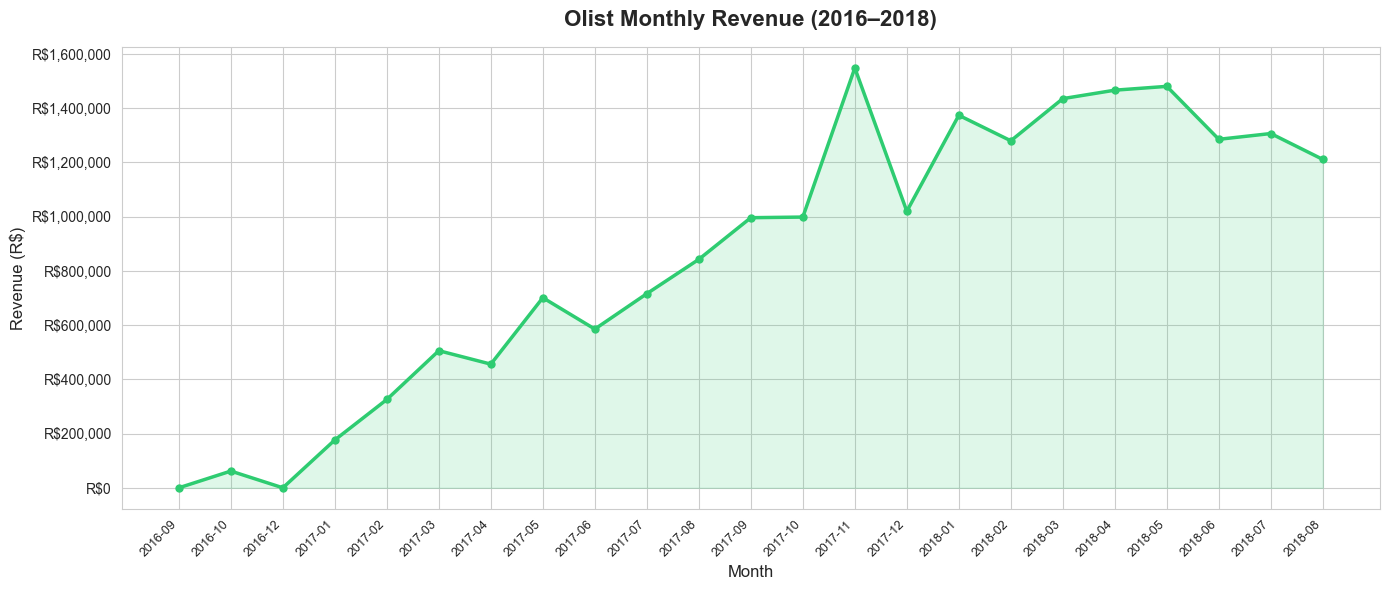

✅ Chart saved to visuals folder!


In [9]:
# Plot monthly revenue over time
print("=== MONTHLY REVENUE CHART ===\n")

# Step 1: Set the visual style
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

# Step 2: Plot the revenue line
plt.plot(
    monthly_revenue['year_month'],
    monthly_revenue['total_revenue'],
    color='#2ecc71',
    linewidth=2.5,
    marker='o',
    markersize=5
)

# Step 3: Fill under the line
plt.fill_between(
    monthly_revenue['year_month'],
    monthly_revenue['total_revenue'],
    alpha=0.15,
    color='#2ecc71'
)

# Step 4: Add labels and title
plt.title('Olist Monthly Revenue (2016–2018)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)

# Step 5: Format y-axis with commas
plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, p: f'R${x:,.0f}')
)

plt.tight_layout()

# Step 6: Save the chart
plt.savefig('../visuals/monthly_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved to visuals folder!")

=== TOP PRODUCT CATEGORIES ===

product_category_name_english  total_revenue  total_orders  avg_order_value
               bed_bath_table     1692714.28          9272       154.543438
                health_beauty     1620684.04          8647       171.283454
        computers_accessories     1549252.47          6529       202.702142
              furniture_decor     1394466.93          6307       170.890555
                watches_gifts     1387046.31          5493       236.818561
               sports_leisure     1349252.93          7529       160.053728
                   housewares     1069787.97          5743       157.437523
                         auto      833610.84          3809       201.403924
                 garden_tools      810614.93          3448       189.928522
                   cool_stuff      744649.32          3559       200.282227


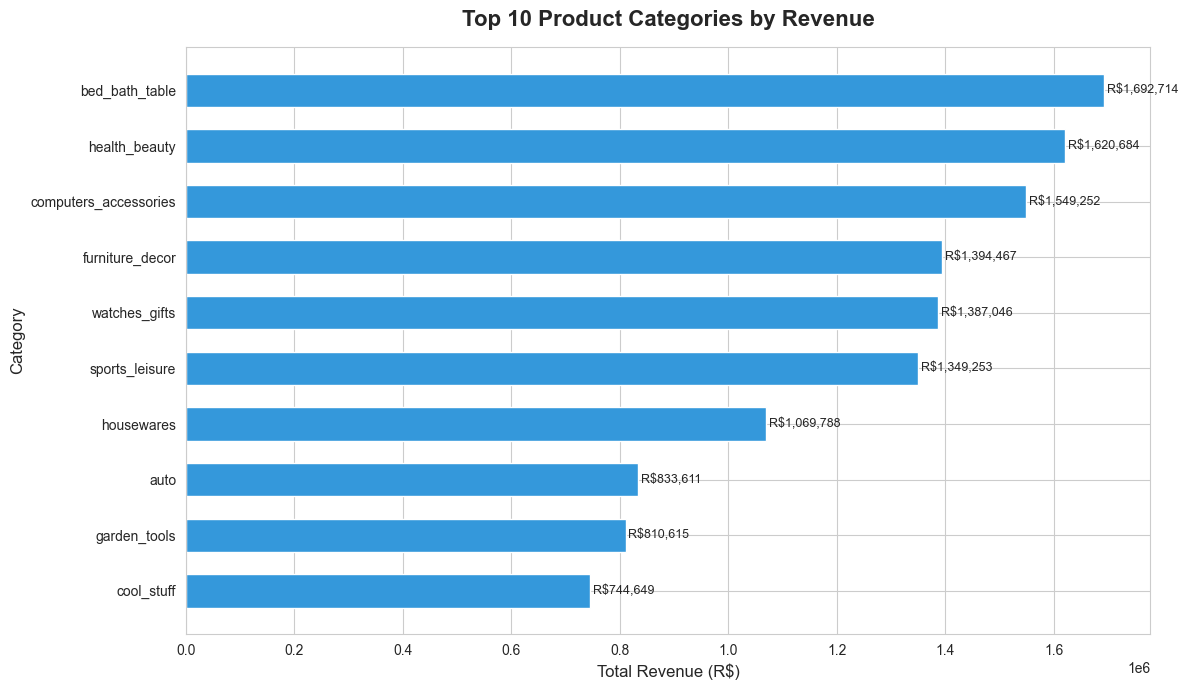

✅ Chart saved!


In [10]:
# Top 10 product categories by revenue
print("=== TOP PRODUCT CATEGORIES ===\n")

# Step 1: Group by english category name
category_revenue = master.groupby('product_category_name_english').agg(
    total_revenue=('total_payment', 'sum'),
    total_orders=('order_id', 'nunique'),
    avg_order_value=('total_payment', 'mean')
).reset_index()

# Step 2: Sort by revenue and take top 10
top_categories = category_revenue.sort_values('total_revenue', ascending=False).head(10)

# Step 3: Print the table
print(top_categories.to_string(index=False))

# Step 4: Plot horizontal bar chart
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

bars = plt.barh(
    top_categories['product_category_name_english'],
    top_categories['total_revenue'],
    color='#3498db',
    edgecolor='white',
    height=0.6
)

# Step 5: Add value labels on each bar
for bar, value in zip(bars, top_categories['total_revenue']):
    plt.text(
        value + 5000,
        bar.get_y() + bar.get_height() / 2,
        f'R${value:,.0f}',
        va='center',
        fontsize=9
    )

plt.title('Top 10 Product Categories by Revenue', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Revenue (R$)', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig('../visuals/top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved!")

=== DELIVERY PERFORMANCE ANALYSIS ===

Delivery status breakdown:
delivery_status
Early      87182
Late        7826
On Time     1462
Name: count, dtype: int64

On-time + Early rate: 91.9%

Average delivery time by status:
delivery_status
Early      10.3
Late       31.1
On Time    16.5
Name: delivery_days, dtype: float64


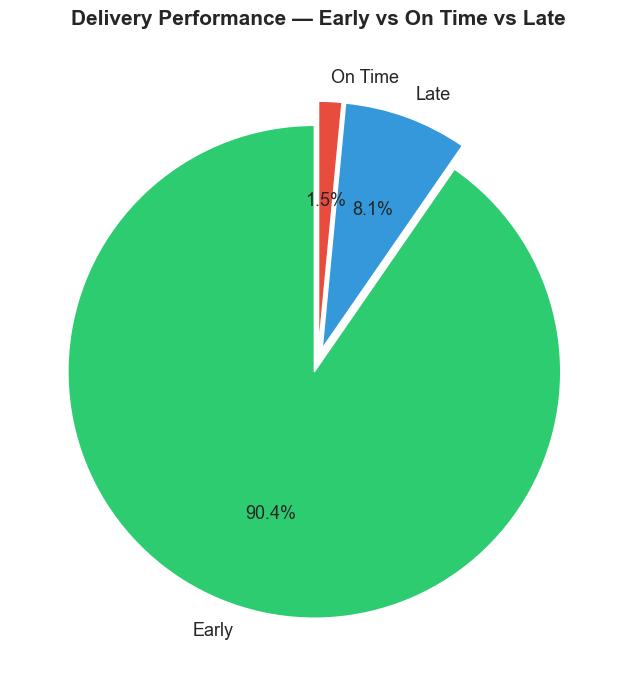


✅ Chart saved!


In [11]:
# Delivery performance analysis
print("=== DELIVERY PERFORMANCE ANALYSIS ===\n")

# Step 1: Classify each order as early, on time or late
def delivery_status(days):
    if days > 0:
        return 'Early'
    elif days == 0:
        return 'On Time'
    else:
        return 'Late'

orders_clean['delivery_status'] = orders_clean['delivery_diff'].apply(delivery_status)

# Step 2: Count each status
status_counts = orders_clean['delivery_status'].value_counts()
print("Delivery status breakdown:")
print(status_counts)
print(f"\nOn-time + Early rate: {((status_counts.get('Early',0) + status_counts.get('On Time',0)) / len(orders_clean) * 100):.1f}%")

# Step 3: Average delivery days by status
print(f"\nAverage delivery time by status:")
print(orders_clean.groupby('delivery_status')['delivery_days'].mean().round(1))

# Step 4: Plot pie chart
plt.figure(figsize=(8, 8))
colors = ['#2ecc71', '#3498db', '#e74c3c']
explode = (0.05, 0.05, 0.05)

plt.pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 13}
)

plt.title('Delivery Performance — Early vs On Time vs Late',
          fontsize=15, fontweight='bold', pad=20)

plt.savefig('../visuals/delivery_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved!")

In [12]:
# RFM Customer Segmentation
print("=== RFM CUSTOMER SEGMENTATION ===\n")

# Step 1: Set reference date as the day after the last order
reference_date = master['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Reference date: {reference_date.date()}")

# Step 2: Calculate R, F, M for each customer
rfm = master.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('total_payment', 'sum')
).reset_index()

print(f"\nRFM table — first 5 rows:")
print(rfm.head())
print(f"\nTotal unique customers: {rfm.shape[0]:,}")
print(f"Average recency: {rfm['recency'].mean():.0f} days")
print(f"Average frequency: {rfm['frequency'].mean():.2f} orders")
print(f"Average monetary value: R${rfm['monetary'].mean():,.2f}")

=== RFM CUSTOMER SEGMENTATION ===

Reference date: 2018-08-30

RFM table — first 5 rows:
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89

Total unique customers: 93,350
Average recency: 238 days
Average frequency: 1.03 orders
Average monetary value: R$211.83


In [13]:
# Score each customer 1-5 on R, F, M
print("=== SCORING CUSTOMERS ===\n")

# Step 1: Score Recency (lower days = better = higher score)
rfm['R_score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1])

# Step 2: Score Frequency (higher = better = higher score)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Step 3: Score Monetary (higher = better = higher score)
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Step 4: Convert to integer
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

# Step 5: Create combined RFM score
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

# Step 6: Assign customer segments
def assign_segment(row):
    r = row['R_score']
    f = row['F_score']
    m = row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost Customers'
    else:
        return 'Potential Loyalists'

rfm['segment'] = rfm.apply(assign_segment, axis=1)

# Step 7: Print segment summary
segment_summary = rfm.groupby('segment').agg(
    customer_count=('customer_unique_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean')
).round(1).reset_index()

print(segment_summary.to_string(index=False))

=== SCORING CUSTOMERS ===

            segment  customer_count  avg_recency  avg_frequency  avg_monetary
            At Risk           13226        393.5            1.1         318.1
          Champions            6459         91.1            1.2         442.1
     Lost Customers            6283        396.2            1.0          56.4
    Loyal Customers           14213        153.5            1.1         267.3
      New Customers           14980         90.9            1.0         204.4
Potential Loyalists           38189        272.0            1.0         143.9


=== RFM SEGMENT CHARTS ===



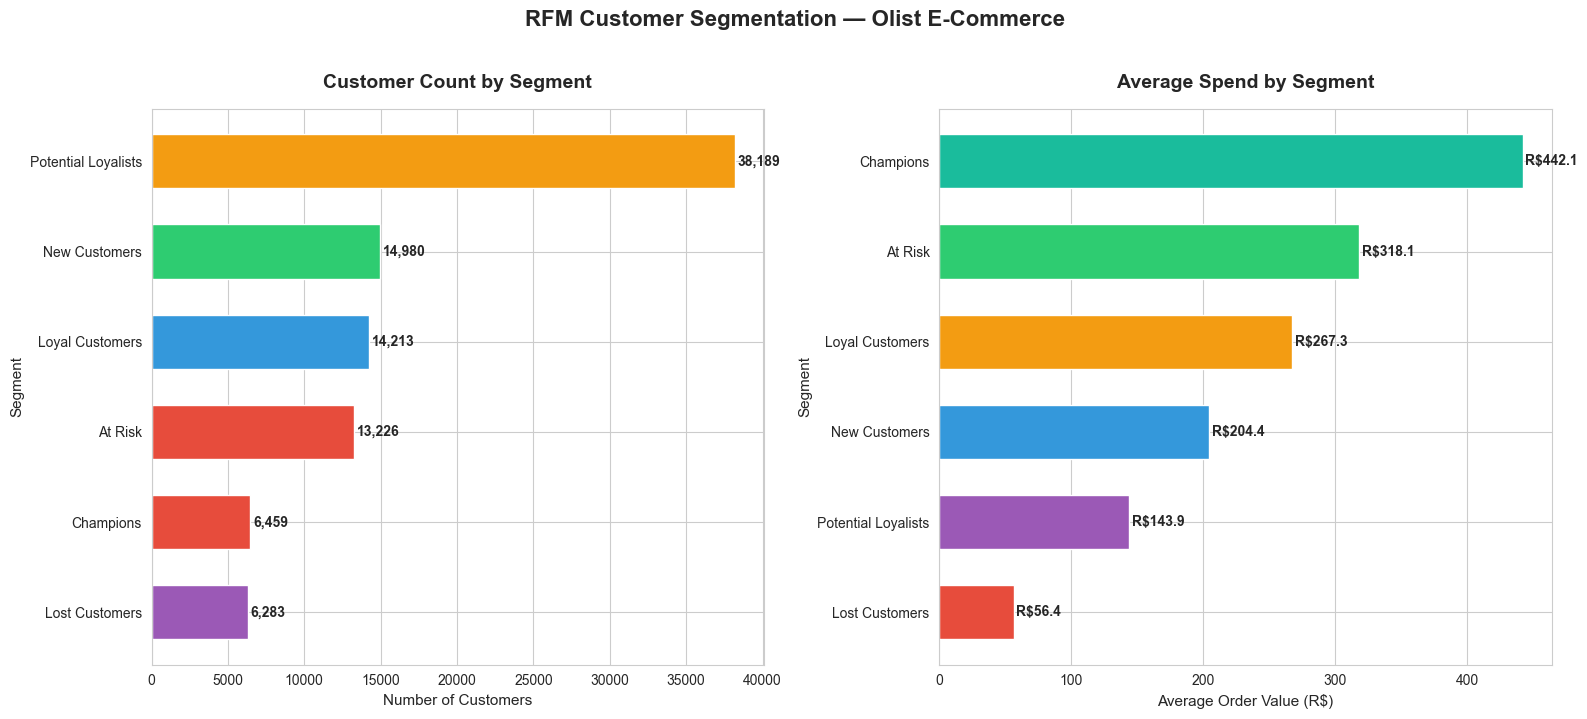

✅ RFM chart saved!


In [14]:
# Visualise RFM segments
print("=== RFM SEGMENT CHARTS ===\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.set_style("whitegrid")

# Chart 1: Customer count per segment
colors = ['#e74c3c', '#f39c12', '#e74c3c', '#2ecc71', '#3498db', '#9b59b6']
segment_summary_sorted = segment_summary.sort_values('customer_count', ascending=True)

bars = axes[0].barh(
    segment_summary_sorted['segment'],
    segment_summary_sorted['customer_count'],
    color=['#9b59b6', '#e74c3c', '#e74c3c', '#3498db', '#2ecc71', '#f39c12'],
    height=0.6,
    edgecolor='white'
)

for bar, value in zip(bars, segment_summary_sorted['customer_count']):
    axes[0].text(
        value + 200,
        bar.get_y() + bar.get_height() / 2,
        f'{value:,}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

axes[0].set_title('Customer Count by Segment', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Number of Customers', fontsize=11)
axes[0].set_ylabel('Segment', fontsize=11)

# Chart 2: Average monetary value per segment
segment_summary_money = segment_summary.sort_values('avg_monetary', ascending=True)

bars2 = axes[1].barh(
    segment_summary_money['segment'],
    segment_summary_money['avg_monetary'],
    color=['#e74c3c', '#9b59b6', '#3498db', '#f39c12', '#2ecc71', '#1abc9c'],
    height=0.6,
    edgecolor='white'
)

for bar, value in zip(bars2, segment_summary_money['avg_monetary']):
    axes[1].text(
        value + 2,
        bar.get_y() + bar.get_height() / 2,
        f'R${value:,.1f}',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

axes[1].set_title('Average Spend by Segment', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Average Order Value (R$)', fontsize=11)
axes[1].set_ylabel('Segment', fontsize=11)

plt.suptitle('RFM Customer Segmentation — Olist E-Commerce',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('../visuals/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ RFM chart saved!")

=== REVIEW SCORE ANALYSIS ===

10 Worst rated categories:
product_category_name_english  avg_review  total_orders  avg_delivery_days
             office_furniture    3.516324          1254          20.386691
              fixed_telephony    3.757937           212          12.235294
        fashion_male_clothing    3.758065           106          12.472000
                        audio    3.835196           348          12.883978
                 home_confort    3.861827           392          13.039627
               bed_bath_table    3.924845          9272          12.336803
        furniture_living_room    3.934694           414          13.294949
              furniture_decor    3.956559          6307          12.404044
            home_construction    3.957770           483          12.758389
    construction_tools_safety    3.967033           159          11.426230

10 Best rated categories:
product_category_name_english  avg_review  total_orders  avg_delivery_days
       books_ge

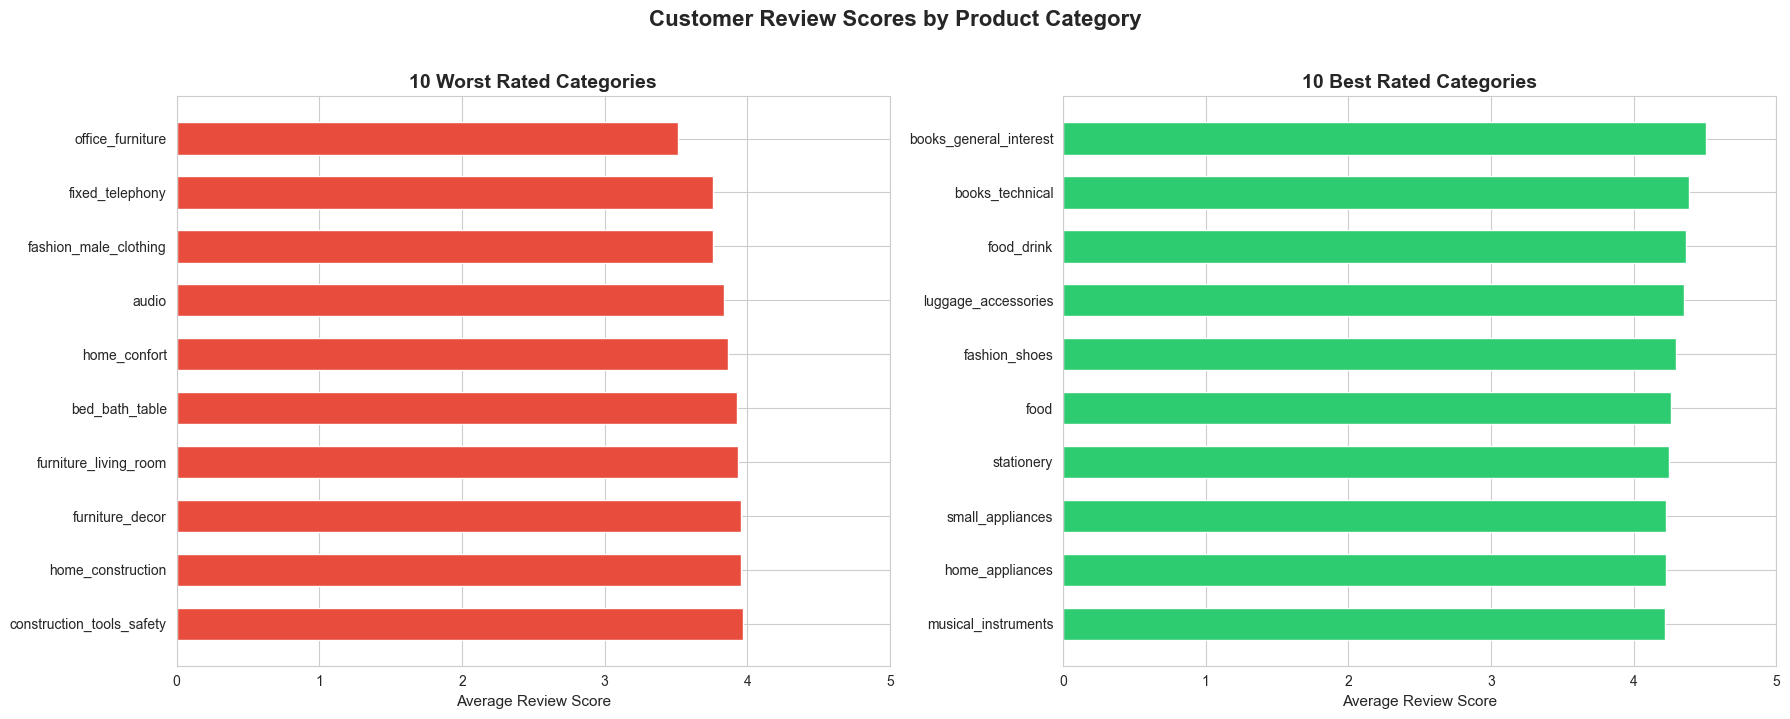


✅ Chart saved!


In [15]:
# Review score analysis by category
print("=== REVIEW SCORE ANALYSIS ===\n")

# Step 1: Average review score by category
category_reviews = master.groupby('product_category_name_english').agg(
    avg_review=('review_score', 'mean'),
    total_orders=('order_id', 'nunique'),
    avg_delivery_days=('delivery_days', 'mean')
).reset_index()

# Step 2: Keep only categories with at least 100 orders
category_reviews = category_reviews[category_reviews['total_orders'] >= 100]

# Step 3: Sort and show bottom 10 (worst rated)
worst_rated = category_reviews.sort_values('avg_review', ascending=True).head(10)
best_rated = category_reviews.sort_values('avg_review', ascending=False).head(10)

print("10 Worst rated categories:")
print(worst_rated[['product_category_name_english', 'avg_review', 'total_orders', 'avg_delivery_days']].to_string(index=False))

print("\n10 Best rated categories:")
print(best_rated[['product_category_name_english', 'avg_review', 'total_orders', 'avg_delivery_days']].to_string(index=False))

# Step 4: Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.set_style("whitegrid")

# Worst rated
axes[0].barh(
    worst_rated['product_category_name_english'],
    worst_rated['avg_review'],
    color='#e74c3c',
    height=0.6,
    edgecolor='white'
)
axes[0].set_title('10 Worst Rated Categories', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Average Review Score', fontsize=11)
axes[0].set_xlim(0, 5)
axes[0].invert_yaxis()

# Best rated
axes[1].barh(
    best_rated['product_category_name_english'],
    best_rated['avg_review'],
    color='#2ecc71',
    height=0.6,
    edgecolor='white'
)
axes[1].set_title('10 Best Rated Categories', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Review Score', fontsize=11)
axes[1].set_xlim(0, 5)
axes[1].invert_yaxis()

plt.suptitle('Customer Review Scores by Product Category',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig('../visuals/review_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved!")

In [16]:
# Export all analysis to Excel
print("=== EXPORTING TO EXCEL ===\n")

# Step 1: Create Excel writer
excel_path = '../excel/olist_analysis.xlsx'
writer = pd.ExcelWriter(excel_path, engine='openpyxl')

# Step 2: Monthly revenue sheet
monthly_revenue.to_excel(writer, sheet_name='Monthly Revenue', index=False)
print("✅ Sheet 1 — Monthly Revenue exported")

# Step 3: Top categories sheet
category_revenue.sort_values('total_revenue', ascending=False).to_excel(
    writer, sheet_name='Category Revenue', index=False)
print("✅ Sheet 2 — Category Revenue exported")

# Step 4: RFM segments sheet
rfm.to_excel(writer, sheet_name='RFM Full Data', index=False)
print("✅ Sheet 3 — RFM Full Data exported")

# Step 5: RFM summary sheet
segment_summary.to_excel(writer, sheet_name='RFM Summary', index=False)
print("✅ Sheet 4 — RFM Summary exported")

# Step 6: Delivery performance sheet
delivery_summary = orders_clean.groupby('delivery_status').agg(
    order_count=('order_id', 'count'),
    avg_delivery_days=('delivery_days', 'mean')
).round(1).reset_index()
delivery_summary.to_excel(writer, sheet_name='Delivery Performance', index=False)
print("✅ Sheet 5 — Delivery Performance exported")

# Step 7: Review scores sheet
category_reviews.sort_values('avg_review', ascending=True).to_excel(
    writer, sheet_name='Review Scores', index=False)
print("✅ Sheet 6 — Review Scores exported")

# Step 8: Save the file
writer.close()
print(f"\n✅ Excel file saved to: {excel_path}")
print("Open it in Excel to see all 6 sheets!")

=== EXPORTING TO EXCEL ===

✅ Sheet 1 — Monthly Revenue exported
✅ Sheet 2 — Category Revenue exported
✅ Sheet 3 — RFM Full Data exported
✅ Sheet 4 — RFM Summary exported
✅ Sheet 5 — Delivery Performance exported
✅ Sheet 6 — Review Scores exported

✅ Excel file saved to: ../excel/olist_analysis.xlsx
Open it in Excel to see all 6 sheets!


In [17]:
# Export clean master dataset for Tableau
print("=== EXPORTING FOR TABLEAU ===\n")

# Select only the columns Tableau needs
tableau_data = master[[
    'order_id',
    'order_purchase_timestamp',
    'year',
    'month',
    'year_month',
    'customer_unique_id',
    'customer_city',
    'customer_state',
    'product_category_name_english',
    'total_payment',
    'delivery_days',
    'delivery_diff',
    'review_score'
]].copy()

# Drop rows with missing category names
tableau_data = tableau_data.dropna(subset=['product_category_name_english'])

# Convert year_month to string for Tableau
tableau_data['year_month'] = tableau_data['year_month'].astype(str)

# Save to data folder
tableau_data.to_csv('../data/olist_tableau_ready.csv', index=False)

print(f"Rows exported: {tableau_data.shape[0]:,}")
print(f"Columns exported: {tableau_data.shape[1]}")
print(f"\nColumn list:")
print(tableau_data.columns.tolist())
print("\n✅ Tableau file saved to data folder!")

=== EXPORTING FOR TABLEAU ===

Rows exported: 108,630
Columns exported: 13

Column list:
['order_id', 'order_purchase_timestamp', 'year', 'month', 'year_month', 'customer_unique_id', 'customer_city', 'customer_state', 'product_category_name_english', 'total_payment', 'delivery_days', 'delivery_diff', 'review_score']

✅ Tableau file saved to data folder!


In [18]:
# Export RFM segments for Tableau
rfm_tableau = rfm[['customer_unique_id', 'recency', 'frequency', 'monetary', 'segment']].copy()
rfm_tableau.to_csv('../data/rfm_segments.csv', index=False)
print(f"✅ RFM segments exported — {rfm_tableau.shape[0]:,} rows")
print(rfm_tableau['segment'].value_counts())

✅ RFM segments exported — 93,350 rows
segment
Potential Loyalists    38189
New Customers          14980
Loyal Customers        14213
At Risk                13226
Champions               6459
Lost Customers          6283
Name: count, dtype: int64
